In [2]:
from functions import *
from firedrake import *
import numpy as np
from IPython.display import display, HTML
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection #need for quad mesh
import gmsh #unstructed mesh
from firedrake.pyplot import triplot #plotting the mesh
import pandas as pd
import logging
opts = {
    "eps_gen_non_hermitian": None,
    "eps_target": 0.95,              # off 1.0, which is a genuine eigenvalue
    "eps_target_magnitude": None,
    "st_type": "sinvert",
    "st_pc_type": "lu",
    "st_pc_factor_mat_solver_type": "mumps",
    "st_mat_mumps_icntl_14": 500,
}      

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


In [16]:
def make_annulus_mesh(
    n=10,
    inner_radius=0.5,
    outer_radius=1.0,
    diagonal="crossed",
    structured=None,
    maxh=None,
    n_angular=None,
    comm=COMM_WORLD,
    name="annulus",
    **kwargs,
):
    """
    Mesh the annulus  inner_radius < |x| < outer_radius.

    Boundary markers
        1 : outer rim,  r = outer_radius
        2 : inner rim,  r = inner_radius

    Unlike the Pac-Man sector there is no degenerate apex, so the structured
    polar branch is genuinely shape-regular: the worst aspect ratio is about
    outer_radius/inner_radius and is independent of n. Both branches are
    therefore usable for convergence studies.

    Parameters mirror make_pacman_mesh. ``n`` is cells per unit length: a
    structured mesh has round(n*(b-a)) cells radially and round(2*pi*n*r_mid)
    angularly, so cells are roughly square at the mean radius.
    """
    a, b = float(inner_radius), float(outer_radius)
    if not 0.0 < a < b:
        raise ValueError("need 0 < inner_radius < outer_radius")
    if structured is None:
        structured = maxh is None
    if structured:
        if maxh is not None:
            raise ValueError("maxh only applies to unstructured meshes; "
                             "pass structured=False")
        return _annulus_structured(n, a, b, diagonal, n_angular,
                                   comm, name, **kwargs)
    return _annulus_unstructured(maxh if maxh is not None else 1.0 / n,
                                 a, b, comm, name, **kwargs)


def _annulus_structured(n, a, b, diagonal, n_angular, comm, name, **kwargs):
    """Polar grid, periodic in theta. Every cell is a quadrilateral."""
    if n < 1:
        raise ValueError("n must be a positive integer")
    if diagonal not in ("crossed", "left", "right"):
        raise ValueError(f"Unknown diagonal '{diagonal}'")

    nr = max(1, int(round(n * (b - a))))
    if n_angular is None:
        nt = max(3, int(round(n * 2.0 * np.pi * 0.5 * (a + b))))
    else:
        nt = int(n_angular)
        if nt < 3:
            raise ValueError("n_angular must be at least 3")

    # Node (i, j) = ring i = 0..nr, spoke j = 0..nt-1, index i*nt + j.
    # Periodic in j: spoke nt is spoke 0, so no duplicated seam.
    ring_r = a + np.arange(nr + 1) * (b - a) / nr
    theta = np.arange(nt) * 2.0 * np.pi / nt
    R, TH = np.meshgrid(ring_r, theta, indexing="ij")
    coords = np.column_stack([(R * np.cos(TH)).ravel(),
                              (R * np.sin(TH)).ravel()])

    i, j = np.meshgrid(np.arange(nr), np.arange(nt), indexing="ij")
    i, j = i.ravel(), j.ravel()
    jp = (j + 1) % nt
    v00 = i * nt + j            # inner, clockwise corner
    v10 = (i + 1) * nt + j      # outer, clockwise
    v11 = (i + 1) * nt + jp     # outer, anticlockwise
    v01 = i * nt + jp           # inner, anticlockwise

    if diagonal == "right":
        cells = [np.column_stack([v00, v10, v11]),
                 np.column_stack([v00, v11, v01])]
    elif diagonal == "left":
        cells = [np.column_stack([v00, v10, v01]),
                 np.column_stack([v10, v11, v01])]
    else:
        quad = np.column_stack([v00, v10, v11, v01])
        centre = len(coords) + np.arange(len(quad))
        coords = np.vstack([coords, coords[quad].mean(axis=1)])
        cells = [np.column_stack([v00, v10, centre]),
                 np.column_stack([v10, v11, centre]),
                 np.column_stack([v11, v01, centre]),
                 np.column_stack([v01, v00, centre])]

    plex = plex_from_cell_list(2, np.vstack(cells), coords, comm)
    _mark_annulus_boundaries(plex, a, b)
    return Mesh(plex, name=name, comm=comm, **kwargs)


def _mark_annulus_boundaries(plex, a, b):
    """1 = outer rim, 2 = inner rim, classified by edge-midpoint radius."""
    plex.createLabel(dmcommon.FACE_SETS_LABEL)
    plex.markBoundaryFaces("boundary_faces")
    if plex.getStratumSize("boundary_faces", 1) > 0:
        coords = plex.getCoordinates()
        coord_sec = plex.getCoordinateSection()
        mid = 0.5 * (a + b)
        for face in plex.getStratumIS("boundary_faces", 1).getIndices():
            x, y = (plex.vecGetClosure(coord_sec, coords, face)
                    .reshape(-1, 2).mean(axis=0))
            plex.setLabelValue(dmcommon.FACE_SETS_LABEL, face,
                               1 if np.hypot(x, y) > mid else 2)
    plex.removeLabel("boundary_faces")


def _annulus_unstructured(maxh, a, b, comm, name, **kwargs):
    """Gmsh annulus: outer curve loop with the inner loop as a hole."""
    import gmsh
    already_running = gmsh.isInitialized()
    if not already_running:
        gmsh.initialize()
    try:
        gmsh.option.setNumber("General.Terminal", 0)
        gmsh.model.add(name)
        geo = gmsh.model.geo
        origin = geo.addPoint(0.0, 0.0, 0.0, maxh)

        def circle(radius):
            # Four quarter-turn arcs; gmsh arcs must span less than half a turn.
            angles = np.arange(4) * 0.5 * np.pi
            pts = [geo.addPoint(radius * np.cos(t), radius * np.sin(t),
                                0.0, maxh) for t in angles]
            return [geo.addCircleArc(pts[k], origin, pts[(k + 1) % 4])
                    for k in range(4)]

        outer, inner = circle(b), circle(a)
        surface = geo.addPlaneSurface([geo.addCurveLoop(outer),
                                       geo.addCurveLoop(inner)])
        geo.synchronize()
        gmsh.model.addPhysicalGroup(1, outer, 1)
        gmsh.model.addPhysicalGroup(1, inner, 2)
        gmsh.model.addPhysicalGroup(2, [surface], 1)
        gmsh.option.setNumber("Mesh.MeshSizeMax", maxh)
        gmsh.model.mesh.generate(2)
        with tempfile.TemporaryDirectory() as tmpdir:
            msh_file = os.path.join(tmpdir, "annulus.msh")
            gmsh.write(msh_file)
            return Mesh(msh_file, name=name, comm=comm, **kwargs)
    finally:
        if already_running:
            gmsh.model.remove()
        else:
            gmsh.finalize()


def snap_annulus(mesh, inner_radius, outer_radius):
    """Push both rims back onto their circles after refinement."""
    V = mesh.coordinates.function_space()
    x = mesh.coordinates.dat.data
    for marker, radius in ((1, outer_radius), (2, inner_radius)):
        nodes = DirichletBC(V, Constant((0.0, 0.0)), marker).nodes
        r = np.linalg.norm(x[nodes], axis=1)
        x[nodes] *= (radius / r)[:, None]


def annulus_hierarchy(nlevels=4, inner_radius=0.5, outer_radius=1.0,
                      maxh=0.15, **kwargs):
    base = make_annulus_mesh(inner_radius=inner_radius,
                             outer_radius=outer_radius,
                             structured=False, maxh=maxh, **kwargs)
    mh = MeshHierarchy(base, nlevels)
    for m in mh:
        snap_annulus(m, inner_radius, outer_radius)
    return mh
def plot_eigenmode(solver, index, title_prefix=""):
    """
    Extracts and plots the vector field and magnitude of a specific eigenmode.
    """
    # 1. Extract the complex eigenvalue and get its real part
    eval_c = solver.eigenvalue(index)
    lr = np.real(eval_c)
    
    # 2. Extract the real eigenfunction
    vr, vi = solver.eigenfunction(index)
    
    # vr is the real part of the eigenfunction, living in your mixed space (V * Q)
    v_field = vr.subfunctions[0]
    
    # =================================================================
    # FIX 1: Project the Nédélec field to a standard CG vector space 
    # so the plotting backend can calculate the magnitude without crashing.
    # =================================================================
    mesh = v_field.function_space().mesh()
    V_plot = VectorFunctionSpace(mesh, "CG", 1)
    v_plot = project(v_field, V_plot)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # =================================================================
    # FIX 2: Safely combine f-strings and raw strings for the LaTeX math
    # =================================================================
    title_str = f"{title_prefix} Mode {index} - Vector Field\n" + r"$\lambda \approx$ " + f"{lr:.4f}"
    
    # 3. Plot the Vector Field (Arrows) using the projected field
    quiver(v_plot, axes=ax1)
    ax1.set_title(title_str)
    ax1.set_aspect('equal')
    
    # 4. Plot the Magnitude (Heatmap) using the projected field
    contour = tripcolor(v_plot, axes=ax2, cmap='inferno')
    fig.colorbar(contour, ax=ax2)
    ax2.set_title(f"{title_prefix} Mode {index} - Magnitude")
    ax2.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()


def table_eigenvalues(eig_list, N_list, dof_list, h_list, exact_eigs=None):
    """
    Generates a table of eigenvalues across different solver runs using pandas.
    Only includes up to the top 10 eigenvalues.
    
    Parameters:
    eig_list (list of lists): The computed eigenvalues for each run.
    N_list (list of int): The mesh resolution (num_cells) for each run.
    dof_list (list of int): The number of Degrees of Freedom for each run.
    h_list (list of float): The maximum cell size (h) for each run.
    exact_eigs (list, optional): Exact eigenvalues to compute convergence rates.
    """
    assert len(eig_list) == len(N_list) == len(dof_list) == len(h_list), "Input lists must match in length."
    
    # Cap the maximum number of rows to 10
    max_eigs = min(10, max(len(run) for run in eig_list))
    
    # 1. Format the eigenvalues into strings and pad to max_eigs
    data_dict = {}
    for j, eigs in enumerate(eig_list):
        col = []
        # Slice the list to only process the first 10 eigenvalues
        for i, val in enumerate(eigs[:10]):
            
            # Format the computed eigenvalue
            if isinstance(val, complex) or np.iscomplexobj(val):
                val_str = f"{np.real(val):.5f} + {np.imag(val):.5f}i"
            else:
                val_str = f"{val:.5f}"
                
            # Compute convergence rate if exact eigenvalues are provided
            rate_str = ""
            if exact_eigs is not None and i < len(exact_eigs) and j > 0:
                exact_val = exact_eigs[i]
                
                # Check if the previous run had an eigenvalue at this index
                if i < len(eig_list[j-1]):
                    prev_val = eig_list[j-1][i]
                    
                    err_curr = abs(val - exact_val)
                    err_prev = abs(prev_val - exact_val)
                    
                    h_curr = h_list[j]
                    h_prev = h_list[j-1]
                    
                    # Prevent division by zero and log of zero errors
                    if h_curr != h_prev and err_curr > 1e-15 and err_prev > 1e-15:
                        # Use h_prev / h_curr to yield a positive rate since h decreases
                        rate = np.log(err_prev / err_curr) / np.log(h_prev / h_curr)
                        rate_str = f" ({rate:.2f})"
                    elif err_curr <= 1e-15:
                        # Reached machine precision / exact match
                        rate_str = " (exact)"
                        
            col.append(val_str + rate_str)
            
        # Pad missing eigenvalues with a dash up to max_eigs
        col += ["-"] * (max_eigs - len(col))
        
        # Create a combined column header for N and DOF
        col_header = f"N={N_list[j]} (DOF={dof_list[j]})"
        data_dict[col_header] = col
        
    # 2. Create the DataFrame
    df = pd.DataFrame(data_dict)

    # Use standard unicode for terminal/Jupyter row indices
    df.index = [f"λ_{i+1}" for i in range(max_eigs)]
    
    return df
    
def run_mesh_sweep(mesh_hierarchy, space_builder, form_builder, bc_builder, wind_func,
                   n_evals=32, solver_opts=None, drop_harmonic=False, **kwargs):
    """
    Iterates over a list or hierarchy of meshes, assembling and solving the eigenvalue 
    problem for each, and recording the computed eigenvalues and degrees of freedom.
    
    Parameters:
    mesh_hierarchy (list/iterable): A collection of Firedrake Mesh objects (e.g., from MeshHierarchy)
    space_builder (callable): Function to build the FunctionSpace (e.g., FEEC_B_N2_2d1k)
    form_builder (callable): Function to build the bilinear forms (e.g., B_formulation_2d1k)
    bc_builder (callable): Function to generate boundary conditions
    n_evals (int): Number of eigenvalues to compute
    solver_opts (dict): SLEPc/PETSc solver options
    drop_harmonic (bool): Flag to drop harmonic/zero modes from the result
    **kwargs: Additional parameters passed to the builders (e.g., degree=1, u=None, eps=Constant(1.0))
    
    Returns:
    eig_list (list of lists): The eigenvalues computed at each mesh level.
    dof_list (list of ints): The total degrees of freedom at each mesh level.
    N_list (list of ints): The cell counts at each mesh level.
    h_list (list of floats): The maximum cell sizes at each mesh level.
    """
    if solver_opts is None:
        solver_opts = {}

    eig_list = []
    dof_list = []
    N_list = []
    h_list = []  # Explicitly initialized here

    for mesh in mesh_hierarchy:
        u = wind_func(mesh)
        N_list.append(mesh.num_cells())
        
        # Rigorously extract max mesh size h
        V_dg0 = FunctionSpace(mesh, "DG", 0)
        
        # Create an empty Function, then interpolate the symbolic CellSize into it
        h_func = Function(V_dg0).interpolate(CellSize(mesh))
        
        # Now h_func is a computed data object, and we can access the underlying array
        h_max = h_func.dat.data_ro.max() 
        h_list.append(float(h_max)) # Cast to float to ensure it's a standard Python scalar
        
        # 1. Build the Function Space
        # Extract 'degree' from kwargs, default to 1 if not provided
        degree = kwargs.get('degree', 1)
        W = space_builder(mesh, degree=degree)
        
        # 2. Build the Bilinear Forms
        # Extract 'u' and 'eps' from kwargs, providing safe defaults
        eps = kwargs.get('eps', Constant(1.0))
        a, m = form_builder(W, u=u, eps=eps)
        
        # 3. Apply Boundary Conditions
        bcs = bc_builder(W)
        
        # 4. Setup and Solve
        eigenvalue_problem = make_eigensolver(a, m, bcs, n_evals=n_evals, opts=solver_opts)
        eigs, eigfs = solve_eigenpairs(eigenvalue_problem, drop_harmonic=drop_harmonic)
        
        # 5. Store Results
        eig_list.append(eigs)
        dof_list.append(W.dim())
        
    return eig_list, dof_list, N_list, h_list


In [17]:
mh = annulus_hierarchy(nlevels=4, inner_radius=0.5, outer_radius=1.0, maxh=0.15)

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?


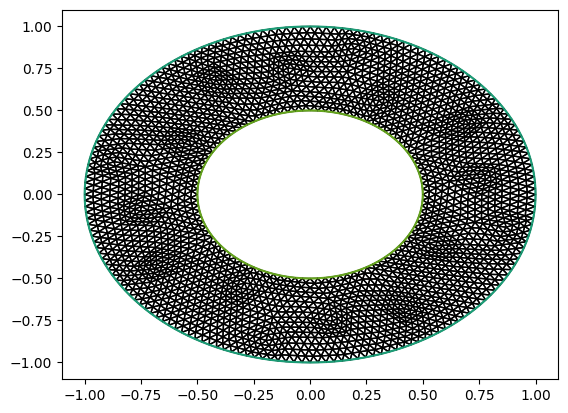

In [18]:
triplot(mh[2])

In [21]:
def wind0(mesh):
    return None

# Map out the three combinations you listed
setups = [
    ("FEEC_B_N1", FEEC_B_N1_2d1k, B_formulation_2d1k, bcs_B_2d1k),
    ("FEEC_B_N2", FEEC_B_N2_2d1k, B_formulation_2d1k, bcs_B_2d1k),
    ("FEEC_A",    FEEC_A_2d1k,    A_formulation_2d1k, bcs_A_2d1k)
]

dataframes = []

for name, space, form, bc in setups:
    eigs, dofs, N_list, h_list = run_mesh_sweep(
        mesh_hierarchy=mh,
        space_builder=space,
        form_builder=form,
        bc_builder=bc,
        wind_func=wind0,
        n_evals=30,
        solver_opts=opts,
        drop_harmonic=False,
        degree=1,                                
        eps=Constant(1.0)        
    )
    
    # Store the dataframe returned by table_eigenvalues
    display(table_eigenvalues(eigs, N_list, dofs, h_list, exact_eigs=eigs[-1]))


,N=300 (DOF=668),N=1200 (DOF=2536),N=4800 (DOF=9872),N=19200 (DOF=38944),N=76800 (DOF=154688)
λ_1,1.83545 + 0.00000i,1.83522 + 0.00000i (1.96),1.83516 + 0.00000i (2.07),1.83514 + 0.00000i (2.53),1.83514 + 0.00000i (exact)
λ_2,1.83545 + 0.00000i,1.83522 + 0.00000i (1.96),1.83516 + 0.00000i (2.07),1.83514 + 0.00000i (2.53),1.83514 + 0.00000i (exact)
λ_3,0.00000 + 0.00000i,0.00000 + 0.00000i (0.01),0.00000 + 0.00000i (0.01),-0.00000 + 0.00000i (-0.20),0.00000 + 0.00000i (exact)
λ_4,7.19356 + 0.00000i,7.19015 + 0.00000i (1.95),7.18919 + 0.00000i (2.08),7.18894 + 0.00000i (2.50),7.18887 + 0.00000i (exact)
λ_5,7.19791 + 0.00000i,7.19122 + 0.00000i (2.03),7.18946 + 0.00000i (2.10),7.18901 + 0.00000i (2.49),7.18889 + 0.00000i (exact)
λ_6,15.69647 + 0.00000i,15.67234 + 0.00000i (2.03),15.66599 + 0.00000i (2.11),15.66435 + 0.00000i (2.49),15.66394 + 0.00000i (exact)
λ_7,15.69647 + 0.00000i,15.67234 + 0.00000i (2.03),15.66599 + 0.00000i (2.11),15.66435 + 0.00000i (2.49),15.66394 + 0.00000i (exact)
λ_8,26.85284 + 0.00000i,26.80151 + 0.00000i (2.00),26.78770 + 0.00000i (2.11),26.78414 + 0.00000i (2.50),26.78326 + 0.00000i (exact)
λ_9,26.88630 + 0.00000i,26.80891 + 0.00000i (2.09),26.78951 + 0.00000i (2.13),26.78460 + 0.00000i (2.50),26.78337 + 0.00000i (exact)
λ_10,40.34353 + 0.00000i,40.22276 + 0.00000i (2.06),40.19186 + 0.00000i (2.13),40.18406 + 0.00000i (2.50),40.18211 + 0.00000i (exact)


,N=300 (DOF=1636),N=1200 (DOF=6272),N=4800 (DOF=24544),N=19200 (DOF=97088),N=76800 (DOF=386176)
λ_1,1.84802 + 0.00000i,1.83850 + 0.00000i (2.03),1.83599 + 0.00000i (2.11),1.83535 + 0.00000i (2.48),1.83519 + 0.00000i (exact)
λ_2,1.84802 + 0.00000i,1.83850 + 0.00000i (2.03),1.83599 + 0.00000i (2.11),1.83535 + 0.00000i (2.48),1.83519 + 0.00000i (exact)
λ_3,0.00000 + 0.00000i,-0.00000 + 0.00000i (-0.12),0.00000 + 0.00000i (0.07),0.00000 + 0.00000i (0.40),0.00000 + 0.00000i (exact)
λ_4,7.26157 + 0.00000i,7.20753 + 0.00000i (2.05),7.19359 + 0.00000i (2.13),7.19005 + 0.00000i (2.48),7.18916 + 0.00000i (exact)
λ_5,7.26615 + 0.00000i,7.20866 + 0.00000i (2.06),7.19387 + 0.00000i (2.13),7.19012 + 0.00000i (2.48),7.18917 + 0.00000i (exact)
λ_6,15.91428 + 0.00000i,15.72726 + 0.00000i (2.07),15.67978 + 0.00000i (2.14),15.66782 + 0.00000i (2.49),15.66482 + 0.00000i (exact)
λ_7,15.91428 + 0.00000i,15.72726 + 0.00000i (2.07),15.67978 + 0.00000i (2.14),15.66782 + 0.00000i (2.49),15.66482 + 0.00000i (exact)
λ_8,27.40067 + 0.00000i,26.93851 + 0.00000i (2.08),26.82200 + 0.00000i (2.14),26.79275 + 0.00000i (2.49),26.78543 + 0.00000i (exact)
λ_9,27.42833 + 0.00000i,26.94496 + 0.00000i (2.09),26.82359 + 0.00000i (2.14),26.79315 + 0.00000i (2.49),26.78553 + 0.00000i (exact)
λ_10,41.51107 + 0.00000i,40.51435 + 0.00000i (2.09),40.26481 + 0.00000i (2.14),40.20234 + 0.00000i (2.49),40.18670 + 0.00000i (exact)


,N=300 (DOF=184),N=1200 (DOF=668),N=4800 (DOF=2536),N=19200 (DOF=9872),N=76800 (DOF=38944)
λ_1,1.86179 + 0.00000i,1.84182 + 0.00000i (2.09),1.83681 + 0.00000i (2.15),1.83555 + 0.00000i (2.49),1.83524 + 0.00000i (exact)
λ_2,1.86179 + 0.00000i,1.84182 + 0.00000i (2.09),1.83681 + 0.00000i (2.15),1.83555 + 0.00000i (2.49),1.83524 + 0.00000i (exact)
λ_3,0.00000 + 0.00000i,0.00000 + 0.00000i (-0.00),0.00000 + 0.00000i (-0.06),0.00000 + 0.00000i (-0.05),-0.00000 + 0.00000i (exact)
λ_4,7.31251 + 0.00000i,7.22013 + 0.00000i (2.07),7.19670 + 0.00000i (2.14),7.19082 + 0.00000i (2.49),7.18935 + 0.00000i (exact)
λ_5,7.31989 + 0.00000i,7.22202 + 0.00000i (2.07),7.19717 + 0.00000i (2.14),7.19094 + 0.00000i (2.49),7.18938 + 0.00000i (exact)
λ_6,16.03066 + 0.00000i,15.75692 + 0.00000i (2.07),15.68720 + 0.00000i (2.14),15.66968 + 0.00000i (2.49),15.66529 + 0.00000i (exact)
λ_7,16.03066 + 0.00000i,15.75692 + 0.00000i (2.07),15.68720 + 0.00000i (2.14),15.66968 + 0.00000i (2.49),15.66529 + 0.00000i (exact)
λ_8,27.61535 + 0.00000i,26.99394 + 0.00000i (2.07),26.83597 + 0.00000i (2.14),26.79626 + 0.00000i (2.49),26.78631 + 0.00000i (exact)
λ_9,27.66962 + 0.00000i,27.00659 + 0.00000i (2.08),26.83907 + 0.00000i (2.14),26.79703 + 0.00000i (2.49),26.78651 + 0.00000i (exact)
λ_10,41.94711 + 0.00000i,40.62520 + 0.00000i (2.08),40.29272 + 0.00000i (2.14),40.20935 + 0.00000i (2.49),40.18847 + 0.00000i (exact)


In [22]:
def wind_func(mesh):
    x,y = SpatialCoordinate(mesh)
    y0 = Constant(np.pi / 2.0)
    return as_vector([sign(y - y0), Constant(0.0)])
    
# Map out the three combinations you listed
setups = [
    ("FEEC_B_N1", FEEC_B_N1_2d1k, B_formulation_2d1k, bcs_B_2d1k),
    ("FEEC_B_N2", FEEC_B_N2_2d1k, B_formulation_2d1k, bcs_B_2d1k),
    ("FEEC_A",    FEEC_A_2d1k,    A_formulation_2d1k, bcs_A_2d1k)
]

dataframes = []

for name, space, form, bc in setups:
    eigs, dofs, N_list, h_list = run_mesh_sweep(
        mesh_hierarchy=mh,
        space_builder=space,
        form_builder=form,
        bc_builder=bc,
        wind_func=wind_func,
        n_evals=30,
        solver_opts=opts,
        drop_harmonic=False,
        degree=1,                                
        eps=Constant(1.0)        
    )
    
    # Store the dataframe returned by table_eigenvalues
    display(table_eigenvalues(eigs, N_list, dofs, h_list, exact_eigs=eigs[-1]))

,N=300 (DOF=668),N=1200 (DOF=2536),N=4800 (DOF=9872),N=19200 (DOF=38944),N=76800 (DOF=154688)
λ_1,-0.00000 + 0.00000i,0.00000 + 0.00000i (0.02),-0.00000 + 0.00000i (-0.08),-0.00000 + 0.00000i (-0.21),0.00000 + 0.00000i (exact)
λ_2,1.99669 + 0.00000i,1.99648 + 0.00000i (1.95),1.99642 + 0.00000i (2.06),1.99640 + 0.00000i (2.53),1.99640 + 0.00000i (exact)
λ_3,2.01426 + 0.00000i,2.01569 + 0.00000i (2.12),2.01603 + 0.00000i (2.16),2.01612 + 0.00000i (2.48),2.01614 + 0.00000i (exact)
λ_4,7.32493 + 0.00000i,7.32427 + 0.00000i (1.43),7.32398 + 0.00000i (1.82),7.32388 + 0.00000i (2.44),7.32386 + 0.00000i (exact)
λ_5,7.33007 + 0.00000i,7.32594 + 0.00000i (2.01),7.32484 + 0.00000i (2.11),7.32455 + 0.00000i (2.52),7.32448 + 0.00000i (exact)
λ_6,15.81963 + 0.00000i,15.80151 + 0.00000i (2.00),15.79664 + 0.00000i (2.10),15.79538 + 0.00000i (2.49),15.79506 + 0.00000i (exact)
λ_7,15.82021 + 0.00000i,15.80164 + 0.00000i (2.01),15.79668 + 0.00000i (2.10),15.79538 + 0.00000i (2.50),15.79506 + 0.00000i (exact)
λ_8,26.97663 + 0.00000i,26.93539 + 0.00000i (1.98),26.92407 + 0.00000i (2.11),26.92113 + 0.00000i (2.50),26.92040 + 0.00000i (exact)
λ_9,27.01050 + 0.00000i,26.94287 + 0.00000i (2.08),26.92590 + 0.00000i (2.13),26.92159 + 0.00000i (2.50),26.92052 + 0.00000i (exact)
λ_10,40.47378 + 0.00000i,40.36760 + 0.00000i (2.06),40.34037 + 0.00000i (2.13),40.33347 + 0.00000i (2.50),40.33176 + 0.00000i (exact)


,N=300 (DOF=1636),N=1200 (DOF=6272),N=4800 (DOF=24544),N=19200 (DOF=97088),N=76800 (DOF=386176)
λ_1,0.00000 + 0.00000i,-0.00000 + 0.00000i (-0.06),0.00000 + 0.00000i (0.18),-0.00000 + 0.00000i (-0.19),0.00000 + 0.00000i (exact)
λ_2,2.00863 + 0.00000i,1.99959 + 0.00000i (2.03),1.99722 + 0.00000i (2.11),1.99661 + 0.00000i (2.48),1.99645 + 0.00000i (exact)
λ_3,2.02757 + 0.00000i,2.01916 + 0.00000i (2.01),2.01692 + 0.00000i (2.11),2.01634 + 0.00000i (2.47),2.01620 + 0.00000i (exact)
λ_4,7.39244 + 0.00000i,7.34150 + 0.00000i (2.05),7.32833 + 0.00000i (2.12),7.32498 + 0.00000i (2.48),7.32413 + 0.00000i (exact)
λ_5,7.39779 + 0.00000i,7.34327 + 0.00000i (2.05),7.32923 + 0.00000i (2.13),7.32566 + 0.00000i (2.48),7.32477 + 0.00000i (exact)
λ_6,16.03672 + 0.00000i,15.85621 + 0.00000i (2.07),15.81038 + 0.00000i (2.14),15.79883 + 0.00000i (2.49),15.79593 + 0.00000i (exact)
λ_7,16.03694 + 0.00000i,15.85626 + 0.00000i (2.07),15.81039 + 0.00000i (2.14),15.79883 + -0.00000i (2.49),15.79593 + 0.00000i (exact)
λ_8,27.52306 + 0.00000i,27.07193 + 0.00000i (2.08),26.95825 + 0.00000i (2.14),26.92971 + 0.00000i (2.49),26.92256 + 0.00000i (exact)
λ_9,27.55115 + 0.00000i,27.07848 + 0.00000i (2.09),26.95986 + 0.00000i (2.14),26.93011 + 0.00000i (2.49),26.92266 + 0.00000i (exact)
λ_10,41.63865 + 0.00042i,40.65832 + 0.00012i (2.09),40.41307 + 0.00003i (2.14),40.35169 + 0.00001i (2.49),40.33634 + 0.00000i (exact)


,N=300 (DOF=184),N=1200 (DOF=668),N=4800 (DOF=2536),N=19200 (DOF=9872),N=76800 (DOF=38944)
λ_1,-0.00000 + 0.00000i,0.00000 + 0.00000i (-0.21),-0.00000 + 0.00000i (3.03),-0.00000 + 0.00000i (-2.73),-0.00000 + 0.00000i (exact)
λ_2,2.02168 + 0.00000i,2.00274 + 0.00000i (2.09),1.99798 + 0.00000i (2.15),1.99680 + 0.00000i (2.49),1.99650 + 0.00000i (exact)
λ_3,2.04224 + 0.00000i,2.02269 + 0.00000i (2.09),2.01779 + 0.00000i (2.15),2.01656 + 0.00000i (2.49),2.01625 + 0.00000i (exact)
λ_4,7.44330 + 0.00000i,7.35452 + 0.00000i (2.05),7.33185 + 0.00000i (2.08),7.32586 + 0.00000i (2.49),7.32436 + 0.00000i (exact)
λ_5,7.45041 + 0.00000i,7.35592 + 0.00000i (2.09),7.33204 + 0.00000i (2.20),7.32636 + 0.00000i (2.50),7.32494 + 0.00000i (exact)
λ_6,16.15175 + 0.00000i,15.88552 + 0.00000i (2.07),15.81770 + 0.00000i (2.14),15.80066 + 0.00000i (2.49),15.79639 + 0.00000i (exact)
λ_7,16.15204 + 0.00000i,15.88561 + 0.00000i (2.07),15.81773 + 0.00000i (2.14),15.80067 + 0.00000i (2.49),15.79640 + 0.00000i (exact)
λ_8,27.73565 + 0.00000i,27.12681 + 0.00000i (2.07),26.97207 + 0.00000i (2.14),26.93318 + 0.00000i (2.49),26.92344 + 0.00000i (exact)
λ_9,27.78932 + 0.00000i,27.13938 + 0.00000i (2.08),26.97516 + 0.00000i (2.14),26.93395 + 0.00000i (2.49),26.92363 + 0.00000i (exact)
λ_10,42.06938 + 0.00038i,40.76785 + 0.00013i (2.08),40.44066 + 0.00004i (2.14),40.35862 + 0.00001i (2.49),40.33808 + 0.00000i (exact)


In [25]:
def wind_func_domain_singularity(mesh):
    x, y = SpatialCoordinate(mesh)
    
    # 1. Define a focal point that actually lies ON the annulus mesh
    x0 = Constant(0.75)
    y0 = Constant(0.0)
    
    # 2. Shift the coordinate system to this point
    x_shift = x - x0
    y_shift = y - y0
    
    # 3. Calculate distance from the singular point, not the origin
    r_shift = sqrt(x_shift**2 + y_shift**2)
    
    # 4. Define components using the shifted coordinates
    u_x = ln(r_shift) + Constant(1.0)
    
    # Use atan2 instead of atan(y/x) to prevent divide-by-zero crashes 
    # anywhere along the vertical line where x_shift = 0
    u_y = -atan2(y_shift, x_shift)
    
    return as_vector([u_x, u_y])
        
# Map out the three combinations you listed
setups = [
    ("FEEC_B_N1", FEEC_B_N1_2d1k, B_formulation_2d1k, bcs_B_2d1k),
    ("FEEC_B_N2", FEEC_B_N2_2d1k, B_formulation_2d1k, bcs_B_2d1k),
    ("FEEC_A",    FEEC_A_2d1k,    A_formulation_2d1k, bcs_A_2d1k)
]

dataframes = []

for name, space, form, bc in setups:
    eigs, dofs, N_list, h_list = run_mesh_sweep(
        mesh_hierarchy=mh,
        space_builder=space,
        form_builder=form,
        bc_builder=bc,
        wind_func=wind_func_domain_singularity,
        n_evals=30,
        solver_opts=opts,
        drop_harmonic=False,
        degree=1,                                
        eps=Constant(1.0)        
    )
    
    # Store the dataframe returned by table_eigenvalues
    display(table_eigenvalues(eigs, N_list, dofs, h_list, exact_eigs=eigs[-1]))

,N=300 (DOF=668),N=1200 (DOF=2536),N=4800 (DOF=9872),N=19200 (DOF=38944),N=76800 (DOF=154688)
λ_1,0.83589 + 0.00000i,0.83305 + 0.00000i (2.08),0.83233 + 0.00000i (2.24),0.83216 + 0.00000i (2.49),0.83212 + 0.00000i (exact)
λ_2,-0.00000 + 0.00000i,0.00000 + 0.00000i (0.19),-0.00000 + 0.00000i (-0.36),-0.00000 + 0.00000i (-0.95),0.00000 + 0.00000i (exact)
λ_3,3.05694 + 0.00000i,3.04961 + 0.00000i (2.12),3.04781 + 0.00000i (2.16),3.04736 + 0.00000i (2.48),3.04725 + 0.00000i (exact)
λ_4,6.26169 + 0.00000i,6.23919 + 0.00000i (2.09),6.23350 + 0.00000i (2.18),6.23212 + 0.00000i (2.49),6.23178 + 0.00000i (exact)
λ_5,7.94627 + 0.00000i,7.93069 + 0.00000i (2.12),7.92690 + 0.00000i (2.15),7.92596 + 0.00000i (2.49),7.92573 + 0.00000i (exact)
λ_6,14.08421 + 0.00000i,14.03758 + 0.00000i (2.08),14.02569 + 0.00000i (2.18),14.02281 + 0.00000i (2.50),14.02209 + 0.00000i (exact)
λ_7,15.70375 + 0.00000i,15.67030 + 0.00000i (2.12),15.66217 + 0.00000i (2.15),15.66014 + 0.00000i (2.49),15.65963 + 0.00000i (exact)
λ_8,24.54223 + 0.00000i,24.45060 + 0.00000i (2.09),24.42744 + 0.00000i (2.18),24.42182 + 0.00000i (2.50),24.42042 + 0.00000i (exact)
λ_9,25.97857 + 0.00000i,25.93653 + 0.00000i (2.11),25.92620 + 0.00000i (2.15),25.92361 + 0.00000i (2.49),25.92297 + 0.00000i (exact)
λ_10,37.30129 + 0.00000i,37.19130 + 0.00000i (2.06),37.16288 + 0.00000i (2.19),37.15603 + 0.00000i (2.51),37.15433 + 0.00000i (exact)


,N=300 (DOF=1636),N=1200 (DOF=6272),N=4800 (DOF=24544),N=19200 (DOF=97088),N=76800 (DOF=386176)
λ_1,0.83446 + 0.00000i,0.83265 + 0.00000i (2.19),0.83222 + 0.00000i (2.39),0.83213 + 0.00000i (2.53),0.83211 + 0.00000i (exact)
λ_2,-0.00000 + 0.00000i,-0.00000 + 0.00000i (-0.08),0.00000 + 0.00000i (0.31),-0.00000 + 0.00000i (-0.16),0.00000 + 0.00000i (exact)
λ_3,3.06143 + 0.00000i,3.05071 + 0.00000i (2.11),3.04809 + 0.00000i (2.15),3.04743 + 0.00000i (2.49),3.04727 + 0.00000i (exact)
λ_4,6.28368 + 0.00000i,6.24451 + 0.00000i (2.11),6.23481 + 0.00000i (2.18),6.23245 + 0.00000i (2.50),6.23186 + 0.00000i (exact)
λ_5,7.98272 + 0.00000i,7.93960 + 0.00000i (2.13),7.92911 + 0.00000i (2.16),7.92651 + 0.00000i (2.49),7.92587 + 0.00000i (exact)
λ_6,14.22161 + 0.00000i,14.07124 + 0.00000i (2.11),14.03403 + 0.00000i (2.17),14.02489 + 0.00000i (2.50),14.02262 + 0.00000i (exact)
λ_7,15.86476 + 0.00000i,15.70986 + 0.00000i (2.12),15.67198 + 0.00000i (2.16),15.66259 + 0.00000i (2.49),15.66024 + 0.00000i (exact)
λ_8,24.98126 + 0.00000i,24.55867 + 0.00000i (2.11),24.45428 + 0.00000i (2.16),24.42852 + 0.00000i (2.50),24.42210 + 0.00000i (exact)
λ_9,26.46114 + 0.00000i,26.05541 + 0.00000i (2.11),25.95575 + 0.00000i (2.15),25.93099 + 0.00000i (2.49),25.92481 + 0.00000i (exact)
λ_10,38.36486 + 0.00000i,37.45344 + 0.00000i (2.11),37.22809 + 0.00000i (2.16),37.17232 + 0.00000i (2.50),37.15842 + 0.00000i (exact)


,N=300 (DOF=184),N=1200 (DOF=668),N=4800 (DOF=2536),N=19200 (DOF=9872),N=76800 (DOF=38944)
λ_1,0.82631 + 0.00000i,0.83055 + 0.00000i (1.98),0.83170 + 0.00000i (2.08),0.83200 + 0.00000i (2.47),0.83208 + 0.00000i (exact)
λ_2,0.00000 + 0.00000i,-0.00000 + 0.00000i (0.13),-0.00000 + 0.00000i (0.12),0.00000 + 0.00000i (-0.34),-0.00000 + 0.00000i (exact)
λ_3,3.05154 + 0.00000i,3.04809 + 0.00000i (2.40),3.04742 + 0.00000i (2.21),3.04727 + 0.00000i (2.51),3.04723 + 0.00000i (exact)
λ_4,6.25637 + 0.00000i,6.23746 + 0.00000i (2.19),6.23305 + 0.00000i (2.21),6.23201 + 0.00000i (2.51),6.23175 + 0.00000i (exact)
λ_5,7.95988 + 0.00000i,7.93365 + 0.00000i (2.19),7.92765 + 0.00000i (2.15),7.92615 + 0.00000i (2.50),7.92578 + 0.00000i (exact)
λ_6,14.20089 + 0.00000i,14.06570 + 0.00000i (2.12),14.03270 + 0.00000i (2.16),14.02457 + 0.00000i (2.50),14.02254 + 0.00000i (exact)
λ_7,15.83267 + 0.00000i,15.70153 + 0.00000i (2.14),15.67000 + 0.00000i (2.14),15.66210 + 0.00000i (2.49),15.66013 + 0.00000i (exact)
λ_8,24.99043 + 0.00000i,24.56054 + 0.00000i (2.11),24.45490 + 0.00000i (2.15),24.42870 + 0.00000i (2.49),24.42215 + 0.00000i (exact)
λ_9,26.51980 + 0.00000i,26.06920 + 0.00000i (2.12),25.95940 + 0.00000i (2.14),25.93193 + 0.00000i (2.49),25.92506 + 0.00000i (exact)
λ_10,38.57358 + 0.00000i,37.50365 + 0.00000i (2.11),37.24086 + 0.00000i (2.15),37.17555 + 0.00000i (2.49),37.15924 + 0.00000i (exact)
